# Introduction
This file will be for creating a Yolo Car recognition model that will be used to detect cars in an input image or video.

# 1. Import Libraries
Libraries that will be used in this file:
1. Ultralytics (Yolov11).
2. Torch.
3. OpenCV.
4. Numpy.
5. Matplotlib.

In [2]:
from ultralytics import YOLO
import torch
import cv2
import numpy as np
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
import matplotlib.pyplot as plt

# 2. Load & Test Yolo Model
In this section, we will simply load the YOLO model and run quick test inference on random road images.

In [3]:
# YOlO Model + Images Folder
car_recog_model = YOLO("yolo11m.pt")
test_imgs_folder = r"I:\AI-ML-Projects\Car Recognition & Classification\Car Object Recognition\Model Test Images"

In [4]:
# Function to read all images present in a folder
def save_imgs(folder_path: str):
    """"
    Save all images present in a folder function

    Args:
        folder_path (str): Path of the folder containing the images.

    Returns:
        imgs_paths (list): List of paths of all the images.
    """
    
    # Image Extensions
    img_extensions = {".jpg", ".jpeg", ".png", ".gif", ".tiff", ".bmp", ".webp"}
    imgs = [
        f for f in os.listdir(folder_path) if os.path.splitext(f)[1].lower() in img_extensions
    ]

    # Read and save images
    imgs_paths = []
    for img in imgs:
        img_path = os.path.join(folder_path, img)
        imgs_paths.append(img_path)

    return imgs_paths

In [5]:
def visualize_imgs(imgs_path):
    # Example Usage of the save imgs function
    imgs = save_imgs(imgs_path)

    # Visualize Images
    fig = plt.figure(figsize=(10, 10))
    imgs_converted = []

    # Read images and convert to RGB for plotting
    for img in imgs:
        img = cv2.imread(img)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        imgs_converted.append(img)

    # Plot Images
    for i, img in enumerate(imgs_converted):
        plt.subplot(2, 3, i + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"Image {i + 1}")

    plt.tight_layout()
    plt.show()

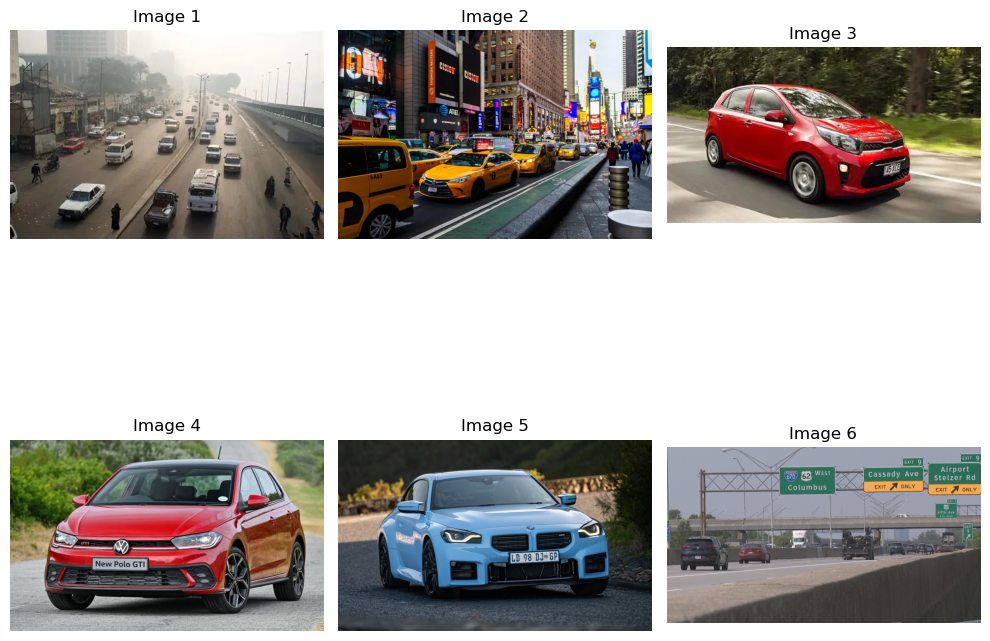

In [6]:
visualize_imgs(test_imgs_folder)

## 2.1. Inference Functions and Results

In [7]:
def run_inference_batch_images(model, output_dir, imgs, visualize=False):
    """
    Run inference on a batch of images using a YOLOv11 model.

    Args:
        model (YOLOv11): The YOLOv11 model to use for inference.
        imgs (list): A list of image paths.

    Returns:
        results (list): A list of YOLOv11 inference results for each image.
    """

    # Create output directory
    output_dir = output_dir
    os.makedirs(output_dir, exist_ok=True)

    # Cars class for COCO
    cars = 2

    # Run inference
    detections = model(imgs)
    
    for img_path, detection in zip(imgs, detections):
        img = cv2.imread(img_path) # Read input image

        # Check if nothing was detected
        if detection.boxes is None:
            continue

        # Get Bounding Boxes
        for box in detection.boxes.data.tolist():
            x1, y1, x2, y2, score, class_id = box
            if class_id == cars:
                x1, y1, x2, y2 = map(int, [x1, y1, x2, y2])
                cv2.rectangle(img, (x1, y1), (x2, y2), (0, 0, 255), 2)
                cv2.putText(img, f"Car: {round(score, 2)}", (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
                
        # Save output image
        output_path = os.path.join(output_dir, os.path.basename(img_path))
        cv2.imwrite(output_path, img)
    
    # Visualize images if required
    if visualize:
        visualize_imgs(output_dir)


0: 640x640 8 persons, 1 bicycle, 19 cars, 1 motorcycle, 1 bus, 3 trucks, 16.9ms
1: 640x640 8 persons, 10 cars, 1 truck, 16.9ms
2: 640x640 1 car, 16.9ms
3: 640x640 1 car, 16.9ms
4: 640x640 1 person, 1 car, 16.9ms
5: 640x640 10 cars, 3 trucks, 16.9ms
Speed: 3.5ms preprocess, 16.9ms inference, 15.3ms postprocess per image at shape (1, 3, 640, 640)


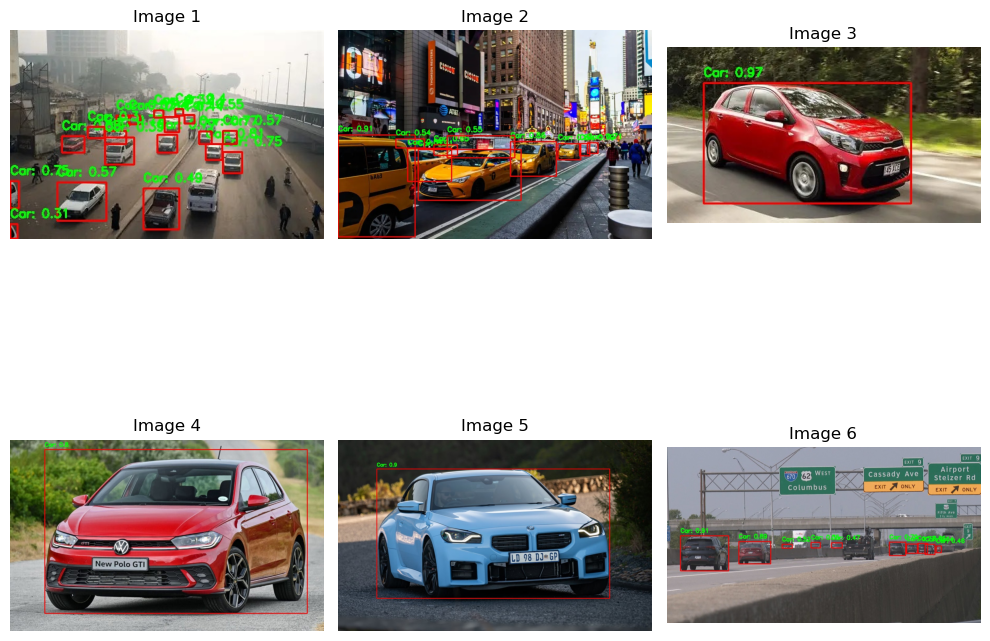

In [8]:
# Test function
run_inference_batch_images(car_recog_model, "inference images", imgs=save_imgs(test_imgs_folder), visualize=True)